# Espacios vectoriales

Hasta ahora hemos trabajado con vectores de $\mathbb{R}^2$ y $\mathbb{R}^3$, donde la suma y el producto por escalar son las operaciones "usuales" (componente a componente). En este cuaderno damos el paso abstracto: un **espacio vectorial** es *cualquier* conjunto con dos operaciones que cumplan una lista de axiomas.

Lo interesante es que:

- hay conjuntos muy distintos de $\mathbb{R}^n$ (matrices, polinomios, funciones, sucesiones) que **sí** son espacios vectoriales;
- y hay operaciones **distintas de las usuales** que convierten a un conjunto conocido en un espacio vectorial (o que lo arruinan por completo).

Usaremos `numpy` para los cálculos numéricos, `sympy` para los polinomios y `matplotlib` para las gráficas.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (5, 5)
rng = np.random.default_rng(2026)

## 1. Definición

Sea $V$ un conjunto no vacío y $\mathbb{K}$ un cuerpo de escalares (en este curso casi siempre $\mathbb{K}=\mathbb{R}$). Supongamos que están definidas dos operaciones:

- una **suma** $\oplus : V\times V \to V$,
- un **producto por escalar** $\odot : \mathbb{K}\times V \to V$.

Decimos que $(V,\oplus,\odot)$ es un **espacio vectorial** si para todos $u,v,w \in V$ y todos $\alpha,\beta \in \mathbb{K}$ se cumplen los **10 axiomas**:

**Cerradura**

1. $u \oplus v \in V$ (cerradura de la suma)
2. $\alpha \odot u \in V$ (cerradura del producto por escalar)

**Axiomas de la suma**

3. $u \oplus v = v \oplus u$ (conmutativa)
4. $(u \oplus v) \oplus w = u \oplus (v \oplus w)$ (asociativa)
5. Existe $\mathbf{0} \in V$ tal que $u \oplus \mathbf{0} = u$ para todo $u$ (**neutro aditivo**)
6. Para cada $u \in V$ existe $-u \in V$ tal que $u \oplus (-u) = \mathbf{0}$ (**inverso aditivo**)

**Axiomas del producto por escalar**

7. $\alpha \odot (u \oplus v) = (\alpha \odot u) \oplus (\alpha \odot v)$ (distributiva respecto a vectores)
8. $(\alpha+\beta) \odot u = (\alpha \odot u) \oplus (\beta \odot u)$ (distributiva respecto a escalares)
9. $\alpha \odot (\beta \odot u) = (\alpha\beta) \odot u$ (asociativa mixta)
10. $1 \odot u = u$ (**neutro multiplicativo**)

> **Ojo con la notación.** Escribimos $\oplus$ y $\odot$ (con círculo) cuando las operaciones **no** son las usuales, para no confundirlas con el $+$ y el $\cdot$ de los números reales. En los axiomas 8 y 9, el $\alpha+\beta$ y el $\alpha\beta$ **sí** son la suma y el producto usuales de $\mathbb{R}$, porque son escalares.

A los elementos de $V$ los llamamos **vectores**, aunque sean matrices, polinomios o funciones.

### 1.1 Consecuencias inmediatas de los axiomas

De los 10 axiomas se deducen (no se postulan) estas propiedades, válidas en *todo* espacio vectorial:

- $0 \odot u = \mathbf{0}$ para todo $u \in V$ (el escalar cero produce el neutro aditivo)
- $\alpha \odot \mathbf{0} = \mathbf{0}$ para todo $\alpha \in \mathbb{K}$
- $(-1) \odot u = -u$
- Si $\alpha \odot u = \mathbf{0}$, entonces $\alpha = 0$ o $u = \mathbf{0}$
- El neutro $\mathbf{0}$ y el inverso $-u$ son **únicos**

Estas consecuencias son una herramienta muy práctica: si en un ejemplo concreto encontramos que $0 \odot u \neq \mathbf{0}$, ya sabemos que **no** es un espacio vectorial, sin revisar los 10 axiomas.

## 2. Ejemplos con las operaciones usuales

### 2.1 $\mathbb{R}^n$

El ejemplo canónico: $V=\mathbb{R}^n$ con
$$(u_1,\dots,u_n) + (v_1,\dots,v_n) = (u_1+v_1,\dots,u_n+v_n), \qquad \alpha(u_1,\dots,u_n) = (\alpha u_1,\dots,\alpha u_n).$$
El neutro es $\mathbf{0}=(0,\dots,0)$ y el inverso de $u$ es $(-u_1,\dots,-u_n)$.

In [2]:
u = np.array([1.0, -2.0, 3.0])
v = np.array([0.5, 4.0, -1.0])
w = np.array([2.0, 0.0, 1.0])
alpha, beta = 3.0, -2.0

print("Conmutativa:   ", np.allclose(u + v, v + u))
print("Asociativa:    ", np.allclose((u + v) + w, u + (v + w)))
print("Neutro:        ", np.allclose(u + np.zeros(3), u))
print("Inverso:       ", np.allclose(u + (-u), np.zeros(3)))
print("Distributiva 1:", np.allclose(alpha * (u + v), alpha * u + alpha * v))
print("Distributiva 2:", np.allclose((alpha + beta) * u, alpha * u + beta * u))
print("Asociativa mix:", np.allclose(alpha * (beta * u), (alpha * beta) * u))
print("1 * u = u:     ", np.allclose(1 * u, u))

Conmutativa:    True
Asociativa:     True
Neutro:         True
Inverso:        True
Distributiva 1: True
Distributiva 2: True
Asociativa mix: True
1 * u = u:      True


### 2.2 Matrices $M_{m\times n}(\mathbb{R})$

El conjunto de todas las matrices reales de tamaño $m\times n$, con la suma entrada a entrada y el producto por escalar usual, es un espacio vectorial. El neutro es la **matriz nula** $0_{m\times n}$ y la dimensión es $mn$.

Note que el producto de matrices **no** interviene en la estructura de espacio vectorial: solo importan la suma y el producto por escalar.

In [3]:
A = np.array([[1, 2], [3, 4]], dtype=float)
B = np.array([[0, -1], [5, 2]], dtype=float)
alpha = 2.5

print("A + B =\n", A + B)
print("\nConmutativa:", np.allclose(A + B, B + A))
print("Neutro (matriz nula):", np.allclose(A + np.zeros((2, 2)), A))
print("Distributiva:", np.allclose(alpha * (A + B), alpha * A + alpha * B))
print("\ndim M_2x2 = 4   (base: E11, E12, E21, E22)")

A + B =
 [[1. 1.]
 [8. 6.]]

Conmutativa: True
Neutro (matriz nula): True
Distributiva: True

dim M_2x2 = 4   (base: E11, E12, E21, E22)


### 2.3 Polinomios $P_n$

$P_n = \{a_0 + a_1x + \cdots + a_nx^n : a_i \in \mathbb{R}\}$, el conjunto de los polinomios de grado **menor o igual** a $n$, es un espacio vectorial con la suma de polinomios y el producto por escalar usuales. El neutro es el polinomio nulo y $\dim P_n = n+1$.

> **Cuidado:** el conjunto de los polinomios de grado **exactamente** $n$ **no** es espacio vectorial: no es cerrado bajo la suma ($x^2$ y $-x^2+x$ son de grado 2, pero su suma es de grado 1) ni contiene al polinomio nulo.

In [4]:
x = sp.symbols("x")
p = 1 + 2*x - x**2
q = 3*x**2 + x - 5
alpha = sp.Rational(1, 2)

print("p(x) =", p)
print("q(x) =", q)
print("p + q =", sp.expand(p + q))
print("(1/2)*p =", sp.expand(alpha * p))
print("\nDistributiva:", sp.simplify(alpha*(p + q) - (alpha*p + alpha*q)) == 0)

# Contraejemplo: grado EXACTAMENTE 2 no es cerrado bajo la suma
r1, r2 = x**2, -x**2 + x
suma = sp.expand(r1 + r2)
print("\nx^2 + (-x^2 + x) =", suma, " -> grado", sp.degree(suma, x))

p(x) = -x**2 + 2*x + 1
q(x) = 3*x**2 + x - 5
p + q = 2*x**2 + 3*x - 4
(1/2)*p = -x**2/2 + x + 1/2

Distributiva: True

x^2 + (-x^2 + x) = x  -> grado 1


### 2.4 Funciones $F(\mathbb{R},\mathbb{R})$

El conjunto de todas las funciones $f:\mathbb{R}\to\mathbb{R}$ con
$$(f+g)(x) = f(x)+g(x), \qquad (\alpha f)(x) = \alpha f(x)$$
es un espacio vectorial (de dimensión infinita). El neutro es la función cero $f(x)=0$.

Aquí los "vectores" son funciones: sumar dos vectores significa sumar las gráficas punto a punto.

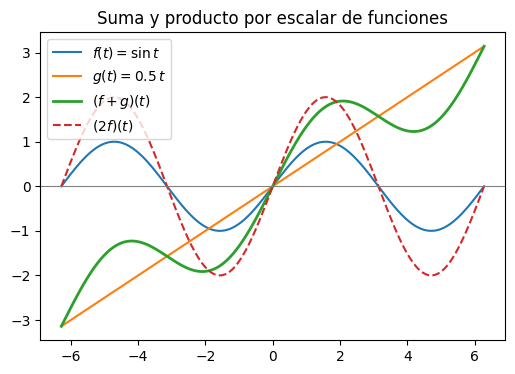

In [5]:
f = lambda t: np.sin(t)
g = lambda t: 0.5 * t
alpha = 2.0

t = np.linspace(-2*np.pi, 2*np.pi, 400)
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t, f(t), label=r"$f(t)=\sin t$")
ax.plot(t, g(t), label=r"$g(t)=0.5\,t$")
ax.plot(t, f(t) + g(t), lw=2, label=r"$(f+g)(t)$")
ax.plot(t, alpha * f(t), "--", label=r"$(2f)(t)$")
ax.axhline(0, color="gray", lw=0.8)
ax.legend()
ax.set_title("Suma y producto por escalar de funciones")
plt.show()

## 3. Una herramienta: verificar los axiomas por fuerza bruta

Antes de pasar a las operaciones no usuales, escribimos una función que prueba los axiomas sobre muchos vectores y escalares elegidos al azar. Esto **no es una demostración**, pero es excelente para *detectar* el axioma que falla y saber qué contraejemplo buscar a mano.

La función recibe:

- `suma(u, v)` y `escalar(a, u)`: las operaciones $\oplus$ y $\odot$;
- `muestra_v()`: genera un vector aleatorio del conjunto;
- `cero`: el candidato a neutro aditivo (si lo conocemos);
- `en_V(u)`: una prueba de pertenencia al conjunto;
- `inverso(u)`: la fórmula del inverso aditivo, si la conocemos. Si no la damos, el código lo busca numéricamente minimizando $\|u\oplus c - \mathbf{0}\|$.

In [6]:
def _igual(a, b, tol=1e-9):
    return np.allclose(np.asarray(a, dtype=float), np.asarray(b, dtype=float), atol=tol, rtol=1e-7)


def _buscar_inverso(suma, u, cero, muestra_v, reinicios=12, pasos=400):
    # Busca c con  u (+) c = cero,  minimizando ||u (+) c - cero|| por descenso aleatorio.
    # Devuelve el c hallado, o None si no existe (o si no se encontro).
    objetivo = lambda c: float(np.linalg.norm(np.asarray(suma(u, c), dtype=float)
                                              - np.asarray(cero, dtype=float)))
    for _ in range(reinicios):
        c = muestra_v()
        mejor = objetivo(c)
        paso = 1.0
        for _ in range(pasos):
            if mejor < 1e-12:
                return c
            cand = c + rng.normal(scale=paso, size=np.shape(c))
            try:
                val = objetivo(cand)
            except (ValueError, FloatingPointError):
                continue
            if np.isfinite(val) and val < mejor:
                c, mejor = cand, val
            else:
                paso *= 0.97
        if mejor < 1e-9:
            return c
    return None


def verificar_axiomas(suma, escalar, muestra_v, cero=None, en_V=lambda u: True,
                      inverso=None, muestra_a=None, n=200):
    # Prueba los 10 axiomas con vectores y escalares aleatorios.
    # Devuelve un diccionario:  axioma -> (se cumplio?, contraejemplo o None)
    if muestra_a is None:
        muestra_a = lambda: rng.uniform(-5, 5)
    res = {}

    def probar(nombre, test, reps=None):
        for _ in range(reps or n):
            fallo = test()
            if fallo is not None:          # el test devuelve el contraejemplo si falla
                res[nombre] = (False, fallo)
                return
        res[nombre] = (True, None)

    def t1():
        u, v = muestra_v(), muestra_v()
        return None if en_V(suma(u, v)) else (u, v)

    def t2():
        a, u = muestra_a(), muestra_v()
        return None if en_V(escalar(a, u)) else (a, u)

    def t3():
        u, v = muestra_v(), muestra_v()
        return None if _igual(suma(u, v), suma(v, u)) else (u, v)

    def t4():
        u, v, w = muestra_v(), muestra_v(), muestra_v()
        return None if _igual(suma(suma(u, v), w), suma(u, suma(v, w))) else (u, v, w)

    def t5():
        u = muestra_v()
        return None if _igual(suma(u, cero), u) else (u,)

    def t6():
        u = muestra_v()
        if inverso is not None:
            return None if _igual(suma(u, inverso(u)), cero) else (u,)
        return None if _buscar_inverso(suma, u, cero, muestra_v) is not None else (u,)

    def t7():
        a, u, v = muestra_a(), muestra_v(), muestra_v()
        return None if _igual(escalar(a, suma(u, v)), suma(escalar(a, u), escalar(a, v))) else (a, u, v)

    def t8():
        a, b, u = muestra_a(), muestra_a(), muestra_v()
        return None if _igual(escalar(a + b, u), suma(escalar(a, u), escalar(b, u))) else (a, b, u)

    def t9():
        a, b, u = muestra_a(), muestra_a(), muestra_v()
        return None if _igual(escalar(a, escalar(b, u)), escalar(a * b, u)) else (a, b, u)

    def t10():
        u = muestra_v()
        return None if _igual(escalar(1.0, u), u) else (u,)

    probar("1.  cerradura suma", t1)
    probar("2.  cerradura escalar", t2)
    probar("3.  conmutativa", t3)
    probar("4.  asociativa suma", t4)
    if cero is not None:
        probar("5.  neutro aditivo", t5)
        probar("6.  inverso aditivo", t6, reps=n if inverso is not None else 5)
    probar("7.  distributiva (vectores)", t7)
    probar("8.  distributiva (escalares)", t8)
    probar("9.  asociativa mixta", t9)
    probar("10. 1 (o) u = u", t10)
    return res


def reporte(res):
    for k, (ok, dato) in res.items():
        marca = "OK   " if ok else "FALLA"
        extra = "" if ok else f"    <- contraejemplo: {dato}"
        print(f"{marca}  {k}{extra}")
    if all(v[0] for v in res.values()):
        print("\n=> ES espacio vectorial (evidencia numerica)")
    else:
        print("\n=> NO es espacio vectorial")

> **Advertencia metodológica.** El chequeo numérico solo da *evidencia*. Para afirmar que algo **sí** es espacio vectorial hay que demostrar los 10 axiomas algebraicamente. En cambio, para afirmar que **no** lo es basta **un** contraejemplo, y el código nos ayuda a encontrarlo.
>
> La prueba del inverso aditivo (axioma 6) es heurística: busca un inverso al azar entre vectores de muestra. Si reporta `FALLA`, conviene analizarlo a mano antes de concluir.

## 4. Operaciones **no usuales**

Aquí está lo interesante del capítulo: cambiar las operaciones cambia por completo la respuesta, aunque el conjunto sea el mismo de siempre.

### 4.1 Ejemplo estrella: $\mathbb{R}^{+}$ con producto y potencia

Sea $V = \mathbb{R}^{+} = \{x \in \mathbb{R} : x > 0\}$, con
$$u \oplus v = u\,v, \qquad \alpha \odot u = u^{\alpha}.$$

O sea: "sumar" es **multiplicar**, y "multiplicar por escalar" es **elevar a la potencia**.

**¿Cuál es el neutro?** Buscamos $\mathbf{0}$ tal que $u \oplus \mathbf{0} = u$, es decir $u\cdot \mathbf{0} = u$, luego
$$\mathbf{0} = 1.$$
El "vector cero" de este espacio es el número $1$. El inverso aditivo de $u$ es $-u = 1/u$, porque $u \oplus (1/u) = u\cdot\frac1u = 1 = \mathbf{0}$.

Verifiquemos algunos axiomas a mano:

- **Axioma 7:** $\alpha\odot(u\oplus v) = (uv)^{\alpha} = u^{\alpha}v^{\alpha} = (\alpha\odot u)\oplus(\alpha\odot v)$ ✓
- **Axioma 8:** $(\alpha+\beta)\odot u = u^{\alpha+\beta} = u^{\alpha}u^{\beta} = (\alpha\odot u)\oplus(\beta\odot u)$ ✓
- **Axioma 9:** $\alpha\odot(\beta\odot u) = (u^{\beta})^{\alpha} = u^{\alpha\beta} = (\alpha\beta)\odot u$ ✓
- **Axioma 10:** $1\odot u = u^{1} = u$ ✓

Las leyes de los exponentes son *exactamente* los axiomas de espacio vectorial. Resulta que $(\mathbb{R}^{+},\oplus,\odot)$ **sí** es un espacio vectorial real, y además de dimensión 1: cualquier $b\neq 1$ es una base, pues todo $u>0$ se escribe $u = b^{\log_b u} = (\log_b u)\odot b$.

In [7]:
suma_pos = lambda u, v: u * v
escalar_pos = lambda a, u: u ** a

res = verificar_axiomas(
    suma=suma_pos,
    escalar=escalar_pos,
    muestra_v=lambda: rng.uniform(0.2, 5.0),
    cero=1.0,                       # el "vector cero" es el numero 1
    inverso=lambda u: 1 / u,        # el "inverso aditivo" es el reciproco
    en_V=lambda u: np.all(u > 0),
    muestra_a=lambda: rng.uniform(-2, 2),
)
reporte(res)

OK     1.  cerradura suma
OK     2.  cerradura escalar
OK     3.  conmutativa
OK     4.  asociativa suma
OK     5.  neutro aditivo
OK     6.  inverso aditivo
OK     7.  distributiva (vectores)
OK     8.  distributiva (escalares)
OK     9.  asociativa mixta
OK     10. 1 (o) u = u

=> ES espacio vectorial (evidencia numerica)


In [8]:
# Consecuencias de los axiomas en este espacio
u = 7.0
print("0 (o) u     =", escalar_pos(0, u), "  (debe ser el vector cero = 1)")
print("(-1) (o) u  =", escalar_pos(-1, u), " = 1/u =", 1/u)

# Una combinacion lineal:  2 (o) 3  (+)  (-1) (o) 5
comb = suma_pos(escalar_pos(2, 3.0), escalar_pos(-1, 5.0))
print("\n2(o)3 (+) (-1)(o)5 =", comb, " = 3^2 / 5 =", 3**2 / 5)

# Todo vector es multiplo de b = 2  =>  dim = 1
b = 2.0
print("\nCoordenada de cada vector en la base {2}:")
for u in [1.0, 8.0, 0.25, 5.0]:
    a = np.log(u) / np.log(b)
    print(f"  u = {u:6} = ({a:8.4f}) (o) 2   ->  comprobacion: {escalar_pos(a, b):.6f}")

0 (o) u     = 1.0   (debe ser el vector cero = 1)
(-1) (o) u  = 0.14285714285714285  = 1/u = 0.14285714285714285

2(o)3 (+) (-1)(o)5 = 1.8  = 3^2 / 5 = 1.8

Coordenada de cada vector en la base {2}:
  u =    1.0 = (  0.0000) (o) 2   ->  comprobacion: 1.000000
  u =    8.0 = (  3.0000) (o) 2   ->  comprobacion: 8.000000
  u =   0.25 = ( -2.0000) (o) 2   ->  comprobacion: 0.250000
  u =    5.0 = (  2.3219) (o) 2   ->  comprobacion: 5.000000


### 4.2 Un fracaso instructivo: $\mathbb{R}^2$ con suma usual y escalar torcido

Sea $V=\mathbb{R}^2$ con la suma usual, pero
$$\alpha \odot (x,y) = (\alpha x,\, 0).$$

La cerradura, la conmutatividad, la asociatividad, el neutro y el inverso se heredan de la suma usual. Pero
$$1 \odot (x,y) = (x,0) \neq (x,y) \quad \text{si } y\neq 0.$$

Falla el **axioma 10**. Es el ejemplo clásico de que ese axioma, que parece trivial, no es redundante: sin él, casi todo lo demás puede cumplirse.

In [9]:
res = verificar_axiomas(
    suma=lambda u, v: u + v,
    escalar=lambda a, u: np.array([a * u[0], 0.0]),
    muestra_v=lambda: rng.uniform(-5, 5, size=2),
    cero=np.zeros(2), inverso=lambda u: -u,
    en_V=lambda u: np.shape(u) == (2,),
)
reporte(res)

OK     1.  cerradura suma
OK     2.  cerradura escalar
OK     3.  conmutativa
OK     4.  asociativa suma
OK     5.  neutro aditivo
OK     6.  inverso aditivo
OK     7.  distributiva (vectores)
OK     8.  distributiva (escalares)
OK     9.  asociativa mixta
FALLA  10. 1 (o) u = u    <- contraejemplo: (array([-2.92112369,  2.76608246]),)

=> NO es espacio vectorial


### 4.3 Suma desplazada en $\mathbb{R}^2$

Sea $V=\mathbb{R}^2$ con
$$(x_1,y_1) \oplus (x_2,y_2) = (x_1+x_2+1,\; y_1+y_2+1), \qquad \alpha \odot (x,y) = (\alpha x, \alpha y).$$

**¿Cuál sería el neutro?** Necesitamos $(x,y)\oplus(a,b) = (x+a+1,\, y+b+1) = (x,y)$, luego $a=b=-1$: el candidato es $\mathbf{0}=(-1,-1)$, ¡que no es el origen!

La suma es conmutativa y asociativa, y cada $(x,y)$ tiene inverso $(-x-2,-y-2)$. Pero probemos el **axioma 8** con $\alpha=\beta=1$ y $u=(1,1)$:
$$(1+1)\odot u = 2\odot(1,1) = (2,2), \qquad (1\odot u)\oplus(1\odot u) = (1,1)\oplus(1,1) = (3,3).$$

Como $(2,2)\neq(3,3)$, **no** es espacio vectorial. También falla el axioma 7.

In [10]:
suma_desp = lambda u, v: u + v + np.array([1.0, 1.0])
escalar_usual = lambda a, u: a * u

res = verificar_axiomas(
    suma=suma_desp, escalar=escalar_usual,
    muestra_v=lambda: rng.uniform(-5, 5, size=2),
    cero=np.array([-1.0, -1.0]), inverso=lambda u: -u - 2.0,
    en_V=lambda u: np.shape(u) == (2,),
)
reporte(res)

u = np.array([1.0, 1.0])
print("\nContraejemplo explicito del axioma 8 (alpha = beta = 1, u = (1,1)):")
print("  (1+1) (o) u      =", escalar_usual(2, u))
print("  1(o)u (+) 1(o)u  =", suma_desp(escalar_usual(1, u), escalar_usual(1, u)))

OK     1.  cerradura suma
OK     2.  cerradura escalar
OK     3.  conmutativa
OK     4.  asociativa suma
OK     5.  neutro aditivo
OK     6.  inverso aditivo
FALLA  7.  distributiva (vectores)    <- contraejemplo: (2.8987076254732234, array([-0.79337474,  3.4228483 ]), array([ 0.11527876, -0.48916426]))
FALLA  8.  distributiva (escalares)    <- contraejemplo: (0.20362495032181194, -3.928331591968238, array([-4.72997073,  1.1963358 ]))
OK     9.  asociativa mixta
OK     10. 1 (o) u = u

=> NO es espacio vectorial

Contraejemplo explicito del axioma 8 (alpha = beta = 1, u = (1,1)):
  (1+1) (o) u      = [2. 2.]
  1(o)u (+) 1(o)u  = [3. 3.]


### 4.4 Arreglando el ejemplo anterior

El problema de 4.3 es que corrimos la suma pero dejamos el producto por escalar sin corregir. Definamos ahora sobre $V=\mathbb{R}^2$:
$$(x_1,y_1) \oplus (x_2,y_2) = (x_1+x_2+1,\; y_1+y_2+1), \qquad \alpha \odot (x,y) = (\alpha x + \alpha - 1,\; \alpha y + \alpha - 1).$$

La idea es un **cambio de coordenadas**: si $T(x,y) = (x+1,\,y+1)$, entonces
$$u \oplus v = T^{-1}\big(T(u) + T(v)\big), \qquad \alpha \odot u = T^{-1}\big(\alpha\,T(u)\big),$$
es decir, trasladamos al mundo usual, operamos ahí y regresamos. Como $T$ es una biyección, **todos** los axiomas se transfieren automáticamente, y el neutro es $T^{-1}(0,0) = (-1,-1)$.

Este truco (transportar la estructura por una biyección) genera infinitos ejemplos de operaciones no usuales que sí funcionan. De hecho, el ejemplo de $\mathbb{R}^{+}$ de 4.1 es el mismo truco con $T(u)=\ln u$.

In [11]:
T     = lambda u: u + 1.0          # al mundo usual
T_inv = lambda z: z - 1.0          # de vuelta

suma_ok    = lambda u, v: T_inv(T(u) + T(v))
escalar_ok = lambda a, u: T_inv(a * T(u))

# Coincide con la formula explicita
u, a = np.array([2.0, -3.0]), 4.0
print("escalar_ok(4, u) =", escalar_ok(a, u),
      "  formula:", np.array([a*u[0] + a - 1, a*u[1] + a - 1]))

res = verificar_axiomas(
    suma=suma_ok, escalar=escalar_ok,
    muestra_v=lambda: rng.uniform(-5, 5, size=2),
    cero=np.array([-1.0, -1.0]), inverso=lambda u: T_inv(-T(u)),
    en_V=lambda u: np.shape(u) == (2,),
)
reporte(res)

escalar_ok(4, u) = [11. -9.]   formula: [11. -9.]


OK     1.  cerradura suma
OK     2.  cerradura escalar
OK     3.  conmutativa
OK     4.  asociativa suma
OK     5.  neutro aditivo
OK     6.  inverso aditivo
OK     7.  distributiva (vectores)
OK     8.  distributiva (escalares)
OK     9.  asociativa mixta
OK     10. 1 (o) u = u

=> ES espacio vectorial (evidencia numerica)


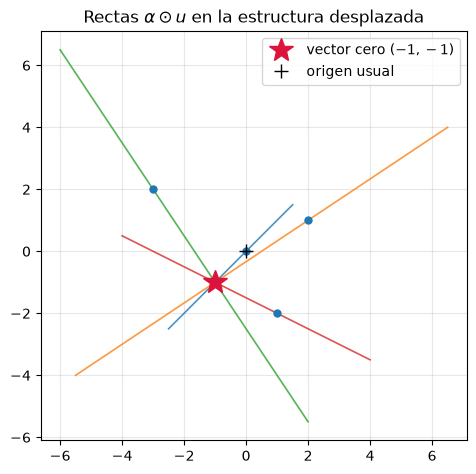

In [12]:
# El "origen" de este espacio esta en (-1,-1): las rectas alpha (o) u pasan por ahi
pts = np.array([[0.0, 0.0], [2.0, 1.0], [-3.0, 2.0], [1.0, -2.0]])
cero_nuevo = np.array([-1.0, -1.0])

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ts = np.linspace(-1.5, 2.5, 60)
for p in pts:
    linea = np.array([escalar_ok(t, p) for t in ts])
    ax.plot(linea[:, 0], linea[:, 1], lw=1.2, alpha=0.8)
    ax.plot(*p, "o", ms=5, color="tab:blue")

ax.plot(*cero_nuevo, "*", ms=18, color="crimson", label=r"vector cero $(-1,-1)$")
ax.plot(0, 0, "k+", ms=10, label="origen usual")
ax.set_aspect("equal"); ax.grid(alpha=0.3); ax.legend()
ax.set_title(r"Rectas $\alpha \odot u$ en la estructura desplazada")
plt.show()

### 4.5 Una suma "por máximo" que falla

Sea $V=\mathbb{R}^2$ con
$$u \oplus v = (\max(x_1,x_2),\ \max(y_1,y_2)), \qquad \alpha\odot u = (\alpha x, \alpha y).$$

La suma es conmutativa y asociativa, pero aquí se derrumba casi todo lo demás:

- **Axioma 5:** el origen no sirve como neutro, pues $\max(u,0)=u$ solo si $u\ge 0$; y ningún otro candidato funciona (un neutro tendría que ser $-\infty$ en cada componente, que no está en $\mathbb{R}^2$).
- **Axioma 6:** sin neutro no hay inverso; y de todas formas el máximo nunca "deshace" nada: $\max(1,v_1)\ge 1$ para todo $v_1$.
- **Axiomas 7 y 8:** con $lpha=eta=1$ y $u=(1,1)$ se tiene $2\odot u = (2,2)$, mientras que $u\oplus u = (1,1)$.

In [13]:
suma_max = lambda u, v: np.maximum(u, v)

res = verificar_axiomas(
    suma=suma_max, escalar=lambda a, u: a * u,
    muestra_v=lambda: rng.uniform(-5, 5, size=2),
    cero=np.zeros(2),
    en_V=lambda u: np.shape(u) == (2,),
)
reporte(res)

u = np.array([1.0, 1.0])
print("\nNo existe inverso de u = (1,1):  max(1, t) >= 1 > 0 para todo t.")
print("Axioma 8 con alpha = beta = 1:", (1 + 1) * u, "vs", suma_max(1 * u, 1 * u))

OK     1.  cerradura suma
OK     2.  cerradura escalar
OK     3.  conmutativa
OK     4.  asociativa suma
FALLA  5.  neutro aditivo    <- contraejemplo: (array([-0.04850868, -4.24571632]),)
FALLA  6.  inverso aditivo    <- contraejemplo: (array([-2.75870996,  2.27972688]),)
FALLA  7.  distributiva (vectores)    <- contraejemplo: (-3.405464383151031, array([-2.29664492, -1.732945  ]), array([-3.68928659, -1.50835362]))
FALLA  8.  distributiva (escalares)    <- contraejemplo: (-1.3820841420392393, 2.2818155166867626, array([-0.05067497, -0.63219736]))
OK     9.  asociativa mixta
OK     10. 1 (o) u = u

=> NO es espacio vectorial

No existe inverso de u = (1,1):  max(1, t) >= 1 > 0 para todo t.
Axioma 8 con alpha = beta = 1: [2. 2.] vs [1. 1.]


### 4.6 Resumen de los ejemplos no usuales

| Conjunto | $u\oplus v$ | $\alpha\odot u$ | Neutro | ¿Espacio vectorial? |
|---|---|---|---|---|
| $\mathbb{R}^{+}$ | $uv$ | $u^{\alpha}$ | $1$ | **Sí** (dim 1) |
| $\mathbb{R}^2$ | usual | $(\alpha x,\, 0)$ | $(0,0)$ | No (falla el 10) |
| $\mathbb{R}^2$ | $u+v+(1,1)$ | usual | $(-1,-1)$ | No (fallan el 7 y el 8) |
| $\mathbb{R}^2$ | $u+v+(1,1)$ | $(\alpha x{+}\alpha{-}1,\ \alpha y{+}\alpha{-}1)$ | $(-1,-1)$ | **Sí** (dim 2) |
| $\mathbb{R}^2$ | $(\max x_i,\ \max y_i)$ | usual | $(0,0)$ | No (falla el 6) |

Moraleja: **el conjunto por sí solo no dice nada**; la estructura la dan las operaciones.

## 5. Subespacios vectoriales

Sea $V$ un espacio vectorial y $W \subseteq V$ no vacío. $W$ es **subespacio** de $V$ si es un espacio vectorial con las **mismas** operaciones de $V$.

No hace falta revisar los 10 axiomas: los axiomas 3, 4, 7, 8, 9 y 10 se heredan de $V$. Basta el **criterio del subespacio**:

$W\subseteq V$ es subespacio si y solo si

1. $\mathbf{0}_V \in W$ (en particular $W \neq \varnothing$),
2. $u,v \in W \implies u \oplus v \in W$ (cerrado bajo la suma),
3. $\alpha \in \mathbb{K},\ u \in W \implies \alpha \odot u \in W$ (cerrado bajo el producto por escalar).

Las condiciones 2 y 3 se pueden juntar en una sola: si $u,v\in W$ y $\alpha,\beta\in\mathbb{K}$, entonces $\alpha u + \beta v \in W$.

**Ejemplos en $\mathbb{R}^2$ y $\mathbb{R}^3$:**

- $\{\mathbf{0}\}$ y $V$ mismo (subespacios *triviales*).
- Rectas **que pasan por el origen**: $W=\{(x,y): y=2x\}$ sí es subespacio; $\{(x,y): y=2x+1\}$ **no** (no contiene al origen).
- Planos que pasan por el origen en $\mathbb{R}^3$.
- El primer cuadrante **no** es subespacio: $(1,1)$ está en él, pero $(-1)(1,1)=(-1,-1)$ no.

In [14]:
def es_subespacio(pertenece, muestra, cero, n=500):
    # Chequeo numerico del criterio del subespacio (operaciones usuales)
    fallas = []
    if not pertenece(cero):
        fallas.append(("no contiene al cero", cero))
    for _ in range(n):
        u, v = muestra(), muestra()
        if not pertenece(u + v):
            fallas.append(("no cerrado bajo la suma", u, v))
            break
    for _ in range(n):
        u, a = muestra(), rng.uniform(-4, 4)
        if not pertenece(a * u):
            fallas.append(("no cerrado bajo el escalar", a, u))
            break
    return (len(fallas) == 0), fallas


# W1: recta y = 2x  (pasa por el origen)
W1 = lambda p: np.isclose(p[1], 2 * p[0])
gen_W1 = lambda: (lambda t: np.array([t, 2 * t]))(rng.uniform(-5, 5))
print("W1 = {y = 2x}          ->", es_subespacio(W1, gen_W1, np.zeros(2))[0])

# W2: recta y = 2x + 1  (no pasa por el origen)
W2 = lambda p: np.isclose(p[1], 2 * p[0] + 1)
gen_W2 = lambda: (lambda t: np.array([t, 2 * t + 1]))(rng.uniform(-5, 5))
ok, fallas = es_subespacio(W2, gen_W2, np.zeros(2))
print("W2 = {y = 2x + 1}      ->", ok, " razones:", [f[0] for f in fallas])

# W3: primer cuadrante
W3 = lambda p: np.all(p >= 0)
gen_W3 = lambda: rng.uniform(0, 5, size=2)
ok, fallas = es_subespacio(W3, gen_W3, np.zeros(2))
print("W3 = primer cuadrante  ->", ok, " razones:", [f[0] for f in fallas])

# W4: plano x + y - z = 0 en R^3
W4 = lambda p: np.isclose(p[0] + p[1] - p[2], 0)
gen_W4 = lambda: (lambda a, b: np.array([a, b, a + b]))(*rng.uniform(-5, 5, size=2))
print("W4 = {x + y - z = 0}   ->", es_subespacio(W4, gen_W4, np.zeros(3))[0])

W1 = {y = 2x}          ->

 True
W2 = {y = 2x + 1}      -> False  razones: ['no contiene al cero', 'no cerrado bajo la suma', 'no cerrado bajo el escalar']
W3 = primer cuadrante  -> False  razones: ['no cerrado bajo el escalar']
W4 = {x + y - z = 0}   -> True


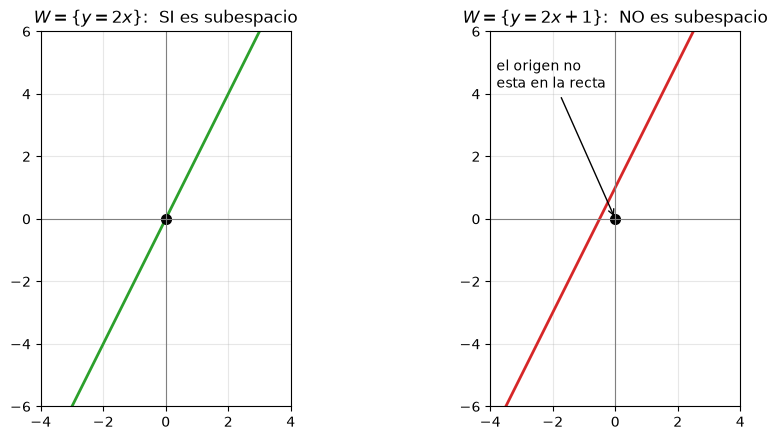

In [15]:
# Un subespacio de R^2 (recta por el origen) frente a un conjunto que no lo es
t = np.linspace(-4, 4, 100)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].plot(t, 2*t, lw=2, color="tab:green")
axes[0].plot(0, 0, "ko", ms=7)
axes[0].set_title(r"$W=\{y=2x\}$:  SI es subespacio")

axes[1].plot(t, 2*t + 1, lw=2, color="tab:red")
axes[1].plot(0, 0, "ko", ms=7)
axes[1].annotate("el origen no\nesta en la recta", xy=(0, 0), xytext=(-3.8, 4.2),
                 arrowprops=dict(arrowstyle="->"))
axes[1].set_title(r"$W=\{y=2x+1\}$:  NO es subespacio")

for ax in axes:
    ax.axhline(0, color="gray", lw=0.8); ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlim(-4, 4); ax.set_ylim(-6, 6); ax.grid(alpha=0.3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

### 5.1 Subespacios en otros espacios

- En $M_{n\times n}$: las matrices **simétricas** ($A^{T}=A$), las **antisimétricas**, las **triangulares superiores**, las de **traza cero**. En cambio, las matrices **invertibles no** forman subespacio (la matriz nula no es invertible).
- En $P_n$: los polinomios con $p(0)=0$, o los polinomios **pares**.
- En $F(\mathbb{R},\mathbb{R})$: las funciones continuas, las derivables, las soluciones de $y''+y=0$.

In [16]:
# Matrices simetricas 2x2: SI es subespacio de M_2x2
def sim():
    a, b, c = rng.uniform(-3, 3, size=3)
    return np.array([[a, b], [b, c]])

A, B = sim(), sim()
a = rng.uniform(-3, 3)
print("A + B simetrica:      ", np.allclose(A + B, (A + B).T))
print("aA simetrica:         ", np.allclose(a * A, (a * A).T))
print("matriz nula simetrica:", np.allclose(np.zeros((2, 2)), np.zeros((2, 2)).T))

# Matrices invertibles: NO es subespacio
I = np.eye(2)
print("\ndet(I) =", np.linalg.det(I), " det(-I) =", np.linalg.det(-I), " -> ambas invertibles")
print("det(I + (-I)) =", np.linalg.det(I + (-I)), " -> la suma NO es invertible")

A + B simetrica:       True
aA simetrica:          True
matriz nula simetrica: True

det(I) = 1.0  det(-I) = 1.0  -> ambas invertibles
det(I + (-I)) = 0.0  -> la suma NO es invertible


## 6. Combinaciones lineales, generado, independencia y base

Estos conceptos tienen sentido en **cualquier** espacio vectorial, usando sus propias operaciones.

- Una **combinación lineal** de $v_1,\dots,v_k$ es $\alpha_1\odot v_1 \oplus \cdots \oplus \alpha_k\odot v_k$.
- El **generado** $\operatorname{gen}\{v_1,\dots,v_k\}$ es el conjunto de todas esas combinaciones; siempre es un subespacio.
- $\{v_1,\dots,v_k\}$ es **linealmente independiente** si la única combinación lineal que da $\mathbf{0}$ es la trivial $\alpha_1=\cdots=\alpha_k=0$.
- Una **base** es un conjunto generador y linealmente independiente; la **dimensión** es su cardinal.

Bases canónicas: $\{e_1,\dots,e_n\}$ en $\mathbb{R}^n$ ($\dim = n$); $\{E_{ij}\}$ en $M_{m\times n}$ ($\dim = mn$); $\{1,x,\dots,x^n\}$ en $P_n$ ($\dim = n+1$).

In [17]:
# Independencia en R^3 via el rango
V = np.array([[1, 2, 3],
              [0, 1, 4],
              [5, 6, 0]], dtype=float)          # vectores por filas
print("rango =", np.linalg.matrix_rank(V), "de 3 filas -> independientes")

W = np.array([[1, 2, 3],
              [2, 4, 6],
              [0, 1, 1]], dtype=float)
print("rango =", np.linalg.matrix_rank(W), "de 3 filas -> dependientes (fila2 = 2*fila1)")

# Independencia en P_2 usando coordenadas en la base {1, x, x^2}
x = sp.symbols("x")
polis = [1 + x, x + x**2, 1 - x**2]
M = sp.Matrix([[sp.expand(p).coeff(x, k) for k in range(3)] for p in polis])
print("\nCoordenadas en {1, x, x^2}:")
sp.pprint(M)
print("rango =", M.rank(), "-> dependientes:  (1+x) - (x+x^2) = 1 - x^2")

rango = 3 de 3 filas -> independientes
rango = 2 de 3 filas -> dependientes (fila2 = 2*fila1)

Coordenadas en {1, x, x^2}:
⎡1  1  0 ⎤
⎢        ⎥
⎢0  1  1 ⎥
⎢        ⎥
⎣1  0  -1⎦
rango = 2 -> dependientes:  (1+x) - (x+x^2) = 1 - x^2


In [18]:
# Independencia en el espacio R^+ de la seccion 4.1
# u y v son dependientes si existe alpha con  alpha (o) u = v,  es decir  u^alpha = v
u, v = 2.0, 8.0
alpha = np.log(v) / np.log(u)
print(f"u = {u}, v = {v}:   {alpha} (o) u = {u**alpha}   -> DEPENDIENTES (dim R^+ = 1)")

# El vector cero de este espacio es 1, y {1} siempre es linealmente dependiente
print("5 (o) 1 =", escalar_pos(5, 1.0), " -> {1} es linealmente dependiente")

u = 2.0, v = 8.0:   3.0 (o) u = 8.0   -> DEPENDIENTES (dim R^+ = 1)
5 (o) 1 = 1.0  -> {1} es linealmente dependiente


## 7. Resumen

- Un **espacio vectorial** es un conjunto con una suma y un producto por escalar que satisfacen **10 axiomas**; los "vectores" pueden ser $n$-uplas, matrices, polinomios o funciones.
- Los axiomas que suelen fallar son el **10** ($1\odot u=u$), el **6** (inverso aditivo) y los distributivos **7** y **8**.
- El **neutro aditivo no tiene por qué ser el origen**: en $\mathbb{R}^{+}$ con $u\oplus v=uv$ el vector cero es $1$; en la estructura desplazada de 4.4 es $(-1,-1)$.
- Para probar que algo **sí** es espacio vectorial hay que verificar los 10 axiomas (o transportar la estructura con una biyección $T$); para probar que **no** lo es basta **un contraejemplo**.
- Un **subespacio** solo requiere tres condiciones: contener al $\mathbf{0}$ y ser cerrado bajo la suma y el producto por escalar.
- Combinación lineal, generado, independencia, base y dimensión se definen igual en cualquier espacio vectorial, usando **sus** operaciones.

## 8. Ejercicios

Resuelve a mano y luego verifica tus respuestas con `numpy`/`sympy` en la celda de código del final.

### A. Axiomas con las operaciones usuales

1. Demuestre que $\mathbb{R}^2$ con las operaciones usuales cumple los axiomas 7 y 8.
2. Verifique que $M_{2\times 3}(\mathbb{R})$ es un espacio vectorial e indique su neutro y su dimensión.
3. Demuestre que el conjunto de polinomios de grado **exactamente** 3 no es espacio vectorial (dé dos razones distintas).
4. ¿Es $\mathbb{C}$ un espacio vectorial sobre $\mathbb{R}$? ¿Cuál es su dimensión? ¿Y visto sobre $\mathbb{C}$?
5. Demuestre, usando solo los axiomas, que $0\odot u = \mathbf{0}$ para todo $u\in V$.

### B. Operaciones no usuales

6. En $V=\mathbb{R}^{+}$ con $u\oplus v = uv$ y $\alpha\odot u = u^{\alpha}$, calcule $\big(3\odot 2\big) \oplus \big((-2)\odot 5\big)$ y escriba el resultado como un solo número.
7. Para el mismo espacio, encuentre el inverso aditivo de $u=10$ y verifique que $u\oplus(-u)=\mathbf{0}$.
8. Sea $V=\mathbb{R}^2$ con $(x_1,y_1)\oplus(x_2,y_2)=(x_1+x_2,\,0)$ y el producto por escalar usual. ¿Qué axiomas fallan?
9. Sea $V=\mathbb{R}$ con $u\oplus v = u+v$ y $\alpha\odot u = 0$ para todo $\alpha$. ¿Qué axioma falla?
10. Sea $V=\mathbb{R}^2$ con $(x_1,y_1)\oplus(x_2,y_2) = (x_1+x_2,\; y_1 y_2)$ y $\alpha\odot(x,y)=(\alpha x,\; y^{\alpha})$. ¿Es espacio vectorial? Si lo es, ¿cuál es el neutro? ¿Sobre qué subconjunto de $\mathbb{R}^2$ habría que trabajar para que todo esté bien definido?
11. Sea $V=\mathbb{R}^2$ con $u\oplus v = u+v-(3,3)$ y $\alpha\odot u = \alpha u - (3\alpha-3,\; 3\alpha-3)$. Muestre que es espacio vectorial hallando la biyección $T$ que lo transporta al $\mathbb{R}^2$ usual, e indique el neutro.
12. Sea $V=\mathbb{R}$ con $u\oplus v = u+v+4$ y $\alpha\odot u = \alpha u + 4\alpha - 4$. Determine el neutro, el inverso aditivo de $u=7$ y verifique el axioma 8.
13. Sea $V=\{(x,y)\in\mathbb{R}^2 : y>0\}$ con $(x_1,y_1)\oplus(x_2,y_2) = (x_1+x_2,\; y_1y_2)$ y $\alpha\odot(x,y) = (\alpha x,\; y^{\alpha})$. Pruebe que es espacio vectorial, halle el neutro y dé una base.
14. Sea $V=\mathbb{R}^2$ con suma usual y $\alpha\odot(x,y) = (\alpha^2 x,\; \alpha^2 y)$. ¿Qué axiomas fallan? Verifíquelo con `verificar_axiomas`.
15. Sea $V=\mathbb{R}^2$ con $u\oplus v = (x_1+x_2,\; y_1+y_2)$ y $\alpha\odot(x,y) = (\alpha x,\; \alpha y + \alpha - 1)$. ¿Cuál es el candidato a neutro? ¿Qué axioma falla?
16. Invente una operación $\oplus$ sobre $\mathbb{R}^2$, distinta de todas las vistas, que **sí** produzca un espacio vectorial, y otra que **no**. Justifique ambas.

### C. Subespacios

17. Determine cuáles de estos subconjuntos de $\mathbb{R}^3$ son subespacios:
    (a) $\{(x,y,z): x+2y-z=0\}$, (b) $\{(x,y,z): x+2y-z=3\}$, (c) $\{(x,y,z): x=y=z\}$,
    (d) $\{(x,y,z): xy=0\}$, (e) $\{(x,y,z): x\ge 0\}$, (f) $\{(x,y,z): x^2+y^2=0\}$.
18. Pruebe que las matrices **antisimétricas** ($A^{T}=-A$) forman un subespacio de $M_{n\times n}$ y calcule su dimensión para $n=3$.
19. ¿Es $\{p\in P_3 : p(1)=0\}$ un subespacio de $P_3$? ¿Y $\{p\in P_3 : p(1)=2\}$?
20. Demuestre que la intersección de dos subespacios es un subespacio. Dé un contraejemplo que muestre que la **unión** no siempre lo es.
21. En el espacio $\mathbb{R}^{+}$ de la sección 4.1, ¿cuáles son **todos** sus subespacios?

### D. Combinaciones lineales, independencia y bases

22. ¿Es $(3,-1,4)$ combinación lineal de $(1,0,1)$ y $(1,-1,2)$?
23. Determine si $\{(1,2,1),(2,1,0),(1,-1,-1)\}$ es linealmente independiente en $\mathbb{R}^3$.
24. Halle una base y la dimensión de $W=\{(x,y,z): x+y+z=0\}$.
25. Muestre que $\{1+x,\ 1-x,\ x^2\}$ es una base de $P_2$ y escriba $p(x)=3+2x-x^2$ en esa base.
26. En el espacio $\mathbb{R}^{+}$ de 4.1, escriba $u=100$ como $\alpha\odot b$ con la base $\{b\}=\{10\}$, y luego con $\{b\}=\{2\}$.
27. En el espacio desplazado de 4.4, halle una base y exprese $(5,7)$ en esa base. *Sugerencia:* trabaje con $T$ y devuélvase con $T^{-1}$.

In [19]:
# Espacio para verificar tus respuestas.
# Ejemplo (ejercicio 14):
# res = verificar_axiomas(
#     suma=lambda u, v: u + v,
#     escalar=lambda a, u: (a**2) * u,
#     muestra_v=lambda: rng.uniform(-5, 5, size=2),
#     cero=np.zeros(2),
#     en_V=lambda u: np.shape(u) == (2,),
# )
# reporte(res)